# **MÓDULO 19**
# Exercício: Estatística Aplicada

**Efetividade de Duas Estratégias de Ensino**

Imagine que uma escola esteja avaliando a eficácia de duas estratégias de ensino de matemática para alunos do ensino médio. Eles querem determinar se há uma diferença significativa no desempenho médio dos alunos entre as duas estratégias.

# **Hipóteses:**

* Hipótese nula (H0): A média das notas dos alunos na estratégia A é igual à média das notas dos alunos na estratégia B.
* Hipótese alternativa (H1): A média das notas na Estratégia B é maior do que a média das notas na Estratégia A.

# **Dados:**

* Amostra da Estratégia A: Notas de 50 alunos que receberam a Estratégia A.
* Amostra da Estratégia B: Notas de 50 alunos que receberam a Estratégia B.

Usaremos um teste Z para comparar as médias das notas entre as duas amostras.

Se o p-valor do teste Z for menor que um nível de significância pré-determinado (por exemplo, α = 0.05), rejeitamos a hipótese nula e concluímos que há uma diferença significativa nas médias das notas entre as duas estratégias de ensino.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

Os dados são criados a seguir:

In [2]:
# Definindo médias e desvios padrão para as notas nas duas estratégias
media_estrategia_A = 70
desvio_padrao_estrategia_A = 10

media_estrategia_B = 75
desvio_padrao_estrategia_B = 12

# Gerando as amostras de notas para cada estratégia de ensino da nossa base
np.random.seed(0)  # Para garantir a reprodutibilidade dos resultados
amostra_estrategia_A = np.random.normal(loc=media_estrategia_A, scale=desvio_padrao_estrategia_A, size=50)
amostra_estrategia_B = np.random.normal(loc=media_estrategia_B, scale=desvio_padrao_estrategia_B, size=50)

print("Notas da Estratégia A:", amostra_estrategia_A[:5])
print("Notas da Estratégia B:", amostra_estrategia_B[:5])

Notas da Estratégia A: [87.64052346 74.00157208 79.78737984 92.40893199 88.6755799 ]
Notas da Estratégia B: [64.25440127 79.64282997 68.87033835 60.83241379 74.66181326]


# 1) De acordo com as informações analisadas o nosso teste é unilateral á direita, esquerda ou bicaudal? Justifique.




In [ ]:
# Sua justificativa aqui

# Unilateral a Direita pois a hipótese alternativa busca saber se a média da Estratégia B é MAIOR que a da Estratégia A.

# 2) Calcule as médias para as duas amostragens e as variâncias. Quais insights você pode retirar comparando os dados?

In [16]:
#Seu código aqui

media_a = amostra_estrategia_A.mean()
media_b = amostra_estrategia_B.mean()

print(f"Média da Estratégia A: ", media_a)
print(f"Média da Estratégia B: ", media_b)

var_a = amostra_estrategia_A.var()
var_b = amostra_estrategia_B.var()

print(f"Variância da Estratégia A: ", var_a)
print(f"Variância da Estratégia B: ", var_b)

# Já é possível perceber uma média maior da estratégia B e uma variância menor, o que apenas olhando nos induziria a pensar que de fato a estratégia B teve resultados melhores. Mas é preciso fazer o teste de significância para ter certeza.

Média da Estratégia A:  71.40559272313098
Média da Estratégia B:  74.74868110507046
Variância da Estratégia A:  126.68018446943104
Variância da Estratégia B:  108.26062024217782


# 3) Imprima os resultados da estatística do teste Z, p value e indique se rejeitaremos ou não a hipótese nula. Justifique sua resposta.

In [ ]:
#Seu código aqui

# Não entendi como fazer o teste Z sem ter a população, então fiz o teste t de Student aqui.

t_stat, p_value = stats.ttest_ind(amostra_estrategia_A, amostra_estrategia_B)

print("T-Statistic:", t_stat)
print("P-value:", p_value)

T-Statistic: -1.5267455833477102
P-value: 0.130045389609515


In [20]:
# E aqui realizei o z test comparando a amostra da estrategia B com a média da amostra da estratégia A como se fosse a população, caso seja essa a ideia do exercício

z_stat = (media_b - media_a) / (desvio_padrao_estrategia_A / np.sqrt(len(amostra_estrategia_B)))

p_value = 1 - stats.norm.cdf(z_stat)

print("Z-Statistic:", z_stat)
print("P-value:", p_value)

Z-Statistic: 2.36392046497537
P-value: 0.009041347101848007


Nos dois testes tivemos resultados diferentes, o que é bem curioso...
Levando é conta o nível de significancia 0.05:
Observando o T-student aceitaríamos a hipótese nula pois o p-value deu 0.13, maior do que o nível de significancia
Porém observando o Z-test regeitaríamos a hipótese nula e aceitaríamos a alternativa, pois o p-value deu 0.009, menor do que o nível de significancia.

Peço pra que na correção me explique por que os dois testes deram tao diferentes e se fiz algo de errado pra que isso ocorresse.

# 4) Para finalizar monte o gráfico da distribuição da estatística do nosso teste Z e explique o que pode ser observado através dele.

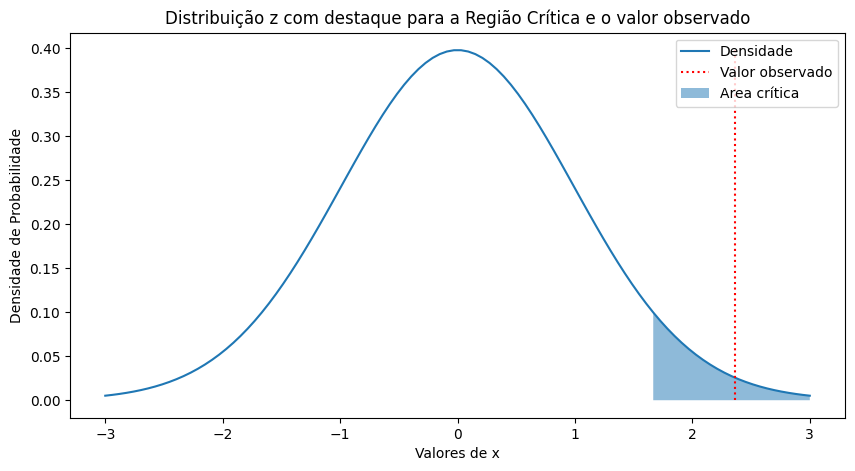

In [ ]:
#Seu código aqui

# Configurações padrão do gráfico
fig, ax = plt.subplots(figsize=(10, 5))

# Parâmetros da densidade sob H0
mu = 0 # É a média da distribuição t sob a hipótese nula, no caso da distribuição t, a média é sempre 0
variance = 1 # É a variância da distribuição t sob a hipótese nula, para a distribuição t, a média é sempre 1
sigma = variance**.5 # É o desvio padrão da distribuição t sob a hipótese nula. Como a variancia é 1, o desvio padrão é a raiz quadrada da variância, ou seja, 1.

# Valores de X e Y para plotar a densidade do nosso gráfico
x = np.linspace(mu - 3*sigma, mu + 3*sigma, 100)
y = stats.t.pdf(x, len(amostra_estrategia_A) + len(amostra_estrategia_B) - 2) # Calcula a densidade da distribuição t para os valores de x

# Essas linhas de código estão calculando os limites da região crítica do test t
low = stats.t.ppf(.95, len(amostra_estrategia_A) + len(amostra_estrategia_B) - 2) # Calcula o valor crítico inferior para a distribuição t
#Len(amostra_estrategia_A) + len(amostra_estrategia_B) - 2 -> Calcula o percentil 95 da distribuição t.

high = np.inf # Define o limite superior da região crítica como infinito

# Gráfico da densidade
ax.plot(x, y, label="Densidade")

# Marcação do valor observado da estatística do teste
ax.vlines(x=[z_stat], ymin=0, ymax=y.max(), colors='r', linestyles='dotted', label='Valor observado')

# Preenchendo a área crítica
plt.fill_between(x, y, where=(low < x) & (x < high), alpha=.5, label='Area crítica') # Pinta a área crítica do gráfico, que é a região onde rejeitamos a hipótese nula.

# Plotagem padrão do gráfico
plt.legend()
plt.xlabel('Valores de x')s
plt.ylabel('Densidade de Probabilidade')
plt.title('Distribuição z com destaque para a Região Crítica e o valor observado')
plt.show()

# Com base no gráfico, podemos ver que o valor observado da estatística do teste está dentro da região crítica, o que indica que rejeitamos a hipótese nula. Isso significa que há evidências suficientes para concluir que a média da Estratégia B é significativamente maior do que a média da Estratégia A, com um nível de significância de 5%.